In [1]:

im_path = "../../../Images/64/"

using Lux, LuxCUDA, MLUtils
using Optimisers, Random, Statistics
using Zygote
using DiffEqFlux, OrdinaryDiffEq
using FFTW
using Images, JLD2
using ComponentArrays
using Plots
using Dates

In [2]:
const cdev = cpu_device()
const gdev = gpu_device()
dev = gdev
rng = Xoshiro()

Xoshiro(0x282be965954bc466, 0xb5491af000d84955, 0x411b671e8624040a, 0xabd4e5f042f05324, 0x406287600b1afa93)

In [3]:
include("model.jl")

Chain(
    layer_1 = Conv((17, 17), 1 => 64, pad=8),     # 18_560 parameters
    layer_2 = SkipConnection(
        connection = +,
        layers = Chain(
            layer_1 = Conv((1, 1), 64 => 256, gelu_tanh),  # 16_640 parameters
            layer_2 = SkipConnection(
                connection = +,
                layers = Chain(
                    layer_(1-3) = Conv((1, 1), 256 => 256, gelu_tanh),  # 197_376 (65_792 x 3) parameters
                ),
            ),
            layer_3 = Conv((1, 1), 256 => 128, gelu_tanh),  # 32_896 parameters
            layer_4 = Conv((1, 1), 128 => 64, gelu_tanh),  # 8_256 parameters
        ),
    ),
    layer_(3-4) = Conv((1, 1), 64 => 64, gelu_tanh),  # 8_320 (4_160 x 2) parameters
    layer_5 = Conv((1, 1), 64 => 1),              # 65 parameters
)         # Total: 282_113 parameters,
          #        plus 0 states.

In [4]:
model = NeuralODE(model_conv, (0.0f0, 1.0f0), Tsit5(); save_everystep = false, sensealg = BacksolveAdjoint(; autojacvec = ZygoteVJP()), reltol = 1e-3, abstol = 1e-4, save_start = false)

NeuralODE(
    model = Chain(
        layer_1 = Conv((17, 17), 1 => 64, pad=8),  # 18_560 parameters
        layer_2 = SkipConnection(
            connection = +,
            layers = Chain(
                layer_1 = Conv((1, 1), 64 => 256, gelu_tanh),  # 16_640 parameters
                layer_2 = SkipConnection(
                    connection = +,
                    layers = Chain(
                        layer_(1-3) = Conv((1, 1), 256 => 256, gelu_tanh),  # 197_376 (65_792 x 3) parameters
                    ),
                ),
                layer_3 = Conv((1, 1), 256 => 128, gelu_tanh),  # 32_896 parameters
                layer_4 = Conv((1, 1), 128 => 64, gelu_tanh),  # 8_256 parameters
            ),
        ),
        layer_(3-4) = Conv((1, 1), 64 => 64, gelu_tanh),  # 8_320 (4_160 x 2) parameters
        layer_5 = Conv((1, 1), 64 => 1),          # 65 parameters
    ),
)         # Total: 282_113 parameters,
          #        plus 0 states.

In [5]:
@load "ps_latestvn.jld2" ps
@load "st_latestvn.jld2" st

ps = ps |> ComponentArray |> cdev
st = st |> cdev


(layer_1 = NamedTuple(), layer_2 = (layer_1 = NamedTuple(), layer_2 = (layer_1 = NamedTuple(), layer_2 = NamedTuple(), layer_3 = NamedTuple()), layer_3 = NamedTuple(), layer_4 = NamedTuple()), layer_3 = NamedTuple(), layer_4 = NamedTuple(), layer_5 = NamedTuple())

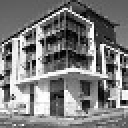

In [6]:
i = 7008
img = load("$im_path$i.jpg")

In [7]:
function spectral_corrupt_image(img::AbstractMatrix{T};
    σ_spatial = T(1e-2), σ_freq = T(6e-5), iter = 3, λ = T(1e-3), s = T(1.0),
) where T <: AbstractFloat
    out = copy(img)
    n, m = size(out)
    k = repeat(T.(0:n-1), 1, m)
    ℓ = repeat(T.(0:m-1)', n, 1)
    freqsq = k.^2 + ℓ.^2
    amplitude = freqsq .+ one(T)
    for i in 1:iter
        out .+= σ_spatial .* randn(n,m) # Spatial corruption
        C = dct(dct(out, 1), 2) # DCT projection
        C .+= σ_freq .* randn(n,m) .* amplitude # Frequency corruption
        C .*= exp.(-λ .* (freqsq.^s)) # Linear Blur
        out .= idct(idct(C, 1), 2) # Back projection
    end
    @. out = clamp(out, zero(T), one(T))              # clamp is cleaner than two passes
    return out
end

#cfunc(img) = add_gaussian_noise(Float32.(img), abs(randn(Float32))*0.1f0 )

cfunc(img) = spectral_corrupt_image( Float32.(img), σ_spatial = Float32(abs(randn(Float32))*2e-3), σ_freq = Float32(abs(randn(Float32))*1e-5), iter = rand(1:10) , λ = Float32(abs(randn(Float32))*1e-2))


cfunc (generic function with 1 method)

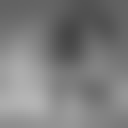

In [8]:
img_corrupt = Gray.(cfunc(img))

In [28]:
function compile_denoiser(model_conv, ps, st)
    denoise = (x, depth) -> begin
        model = NeuralODE(model_conv, (0.0f0, Float32(depth)), Tsit5(); save_everystep = false, sensealg = BacksolveAdjoint(; autojacvec = ZygoteVJP()), reltol = 1e-3, abstol = 1e-4, save_start = false)
        inter = zeros(Float32,64,64,1,1)
        inter[:,: ,1,1] .= x
        y, st = model(x, ps, st)
        y_pred = y[1][:,:,1,1]
        return y_pred
    end
    return denoise
end
denoise = compile_denoiser(model_conv, ps, st)

#compile_denoiser##12 (generic function with 1 method)

In [29]:
y_pred = denoise(Float32.(img_corrupt),2.0)
Gray.(y_pred)

DimensionMismatch: DimensionMismatch: Rank of x and w must match! (2 vs. 4)

In [11]:
y, st = model_conv(x,ps,st)

UndefVarError: UndefVarError: `x` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [12]:
z = copy(x)
for i in 1:100
    y, st = model_conv(z,ps,st)
    z .+= y
end


UndefVarError: UndefVarError: `x` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [13]:
Gray.(z[:,:,1,1])

UndefVarError: UndefVarError: `z` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.